# 01b. Iran Age-Specific Mortality Table

**Purpose.** Build `data/mortality_iran.json` (Iran Male, 2024) using
the UN World Population Prospects 2024 abridged life table, validate
it against the `MortalityFile` schema, and compare it side-by-side
with the Poland reference table that ships with the model.

**Why a separate notebook?** This notebook replaces the previous `--from-wpp` CLI invocation
so the build, validation, and comparison are reproducible, versioned, and
inspectable. The pure-Python functions in `notebook_tools/iran_mortality.py`
do the heavy lifting; this notebook is a thin orchestrator.

**Methodology in one paragraph.** The WPP publishes
age-specific mortality rates `m(x, n)` in 5-year buckets (with
1-year for age 0 and an open 100+ bucket) as model-based estimates
that fold in vital registration, sibling histories, and indirect
techniques. We read Male 2024 (Median variant, Model-based
Estimates, not Projection), aggregate the 1-year rates by 5-year
bucket where the WPP only provides them, population-weight the
90-94 / 95-99 / 100+ rows into the single Poland "90+" bucket, and
emit the result in the same schema as `data/mortality.json` (Poland).
The Male curve is the right input for this Markov model because
hemophilia is X-linked recessive - severe disease is essentially
male-only.

**citations:**

* United Nations, Department of Economic and Social Affairs,
  Population Division (2024). *World Population Prospects 2024*.
  Online edition. https://population.un.org/wpp/
* Preston, S. H., Heuveline, P., & Guillot, M. (2001).
  *Demography: Measuring and Modeling Population Processes*.
  Blackwell, Chapter 3 (cohort-component method).
* Statistical Centre of Iran (SCI), national population estimates
  (the `Iran_<year>.csv` files in `data/raw/`).


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from app.notebook_tools.iran_mortality import (
    POLAND_AGE_BUCKETS,
    build_mortality_from_wpp,
    compare_to_reference,
    validate_mortality_table,
    write_mortality_json,
)

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT.name != "markov-chain-3-14" and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
print(f"Project root: {PROJECT_ROOT}")

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_DIR = PROJECT_ROOT / "data"
WPP_CSV = DATA_RAW / "population-un-data-portal-iran.csv"
POP_CSV = DATA_RAW / "Iran_2024.csv"
POLAND_JSON = DATA_DIR / "mortality.json"
OUTPUT_JSON = DATA_DIR / "mortality_iran.json"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

Project root: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14


In [2]:
# Sanity check the inputs exist before going further.
required = {
    "UN WPP export (Iran, Male, 2024)": WPP_CSV,
    "Iran 2024 population (for 90+ weighting)": POP_CSV,
    "Poland reference mortality": POLAND_JSON,
}
for name, path in required.items():
    status = "OK" if path.exists() else "MISSING"
    print(f"  [{status}] {name}: {path}")
assert all(p.exists() for p in required.values()), (
    "Missing input(s). See the README in data/raw/ for how to obtain them."
)


  [OK] UN WPP export (Iran, Male, 2024): C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\data\raw\population-un-data-portal-iran.csv
  [OK] Iran 2024 population (for 90+ weighting): C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\data\raw\Iran_2024.csv
  [OK] Poland reference mortality: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\data\mortality.json


## 1. Poland reference table (baseline)

The Poland table ships with the model (`data/mortality.json`) and is
the schema template. It is the same shape every country-specific
table must match. We load it here for the side-by-side comparison
in section 4.


In [3]:
poland = json.loads(POLAND_JSON.read_text(encoding="utf-8"))
print("Poland table:")
print(f"  use_age_specific: {poland['use_age_specific']}")
print(f"  crude_annual_rate: {poland['crude_annual_rate']*1000:.3f} per 1000")
print(f"  buckets: {len(poland['age_specific'])}")
poland_df = pl.DataFrame(
    {
        "age_bucket": list(poland["age_specific"].keys()),
        "poland_per_1000": [v * 1000.0 for v in poland["age_specific"].values()],
    }
)
poland_df


Poland table:
  use_age_specific: True
  crude_annual_rate: 12.800 per 1000
  buckets: 20


age_bucket,poland_per_1000
str,f64
"""0""",3.69
"""1-4""",0.15
"""5-9""",0.09
"""10-14""",0.12
"""15-19""",0.36
…,…
"""70-74""",26.86
"""75-79""",40.8
"""80-84""",65.25


## 2. Iran mortality table from UN WPP 2024

We build the table directly from the WPP export. The 90+ combination
uses Male population weights from `Iran_2024.csv` so the 90+
Poland bucket is the population-weighted mean of the WPP's
90-94, 95-99, and 100+ rates. The crude annual rate is computed
from the same population weights.


In [4]:
iran_table = build_mortality_from_wpp(
    wpp_csv=WPP_CSV,
    year=2024,
    sex="Male",
    pop_csv=POP_CSV,
)
print("Source block:")
for k, v in iran_table["source"].items():
    print(f"  {k}: {v}")


Source block:
  country: Iran
  method: un_wpp_abridged
  wpp_csv: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\data\raw\population-un-data-portal-iran.csv
  year: 2024
  sex: Male
  pop_csv: C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\data\raw\Iran_2024.csv
  calculator_version: 1.0.0
  citation: United Nations DESA, Population Division (2024). World Population Prospects 2024.


The resulting table is a plain dict matching the
`MortalityFile` schema. The 20 Poland buckets are filled
(`None`-free) when the WPP + population data are both available.


In [5]:
iran_df = pl.DataFrame(
    {
        "age_bucket": list(iran_table["age_specific"].keys()),
        "iran_per_1000": [
            (v * 1000.0) if v is not None else None
            for v in iran_table["age_specific"].values()
        ],
    }
)
iran_df


age_bucket,iran_per_1000
str,f64
"""0""",9.95196
"""1-4""",0.43471
"""5-9""",0.42198
"""10-14""",0.38149
"""15-19""",1.03169
…,…
"""70-74""",26.45903
"""75-79""",54.93138
"""80-84""",108.00575


## 3. Validation

`validate_mortality_table` round-trips the table through the
Pydantic `MortalityFile` schema, confirms all 20 Poland buckets are
present, each rate is in `(0, 1]`, and the crude rate is in the
expected Iran range. We run it in non-strict mode first to see any
warnings, then in strict mode to halt the notebook if anything is
wrong.


In [6]:
warnings_list = validate_mortality_table(iran_table, strict=False)
if warnings_list:
    print("Validation warnings:")
    for w in warnings_list:
        print(f"  - {w}")
else:
    print("Validation passed with no warnings.")


Validation passed with no warnings.


In [7]:
# Strict mode raises on any warning; useful as a CI gate.
validate_mortality_table(iran_table, strict=True)
print("Strict validation passed.")


Strict validation passed.


## 4. Iran vs Poland: side-by-side

A polars DataFrame with the two curves and the ratio (Iran / Poland)
per 1000 person-years. A bucket missing in either side is `null`.


In [8]:
comparison = compare_to_reference(iran_table, POLAND_JSON)
comparison


age_bucket,iran_per_1000,reference_per_1000,ratio_iran_over_ref
str,f64,f64,f64
"""0""",9.95196,3.69,2.697008
"""1-4""",0.43471,0.15,2.898067
"""5-9""",0.42198,0.09,4.688667
"""10-14""",0.38149,0.12,3.179083
"""15-19""",1.03169,0.36,2.865806
…,…,…,…
"""70-74""",26.45903,26.86,0.985072
"""75-79""",54.93138,40.8,1.346357
"""80-84""",108.00575,65.25,1.655261


**How to read this.**

* `iran_per_1000` and `reference_per_1000` are deaths per 1,000
  person-years. A value of 9.952 for age 0 means about 1% of
  one-year-old boys die each year.
* `ratio_iran_over_ref` is the Iran rate divided by the Poland
  rate. A ratio of 2.7 at age 0 means Iranian infant boys die
  at 2.7x the rate of Polish infant boys; a ratio below 1 means
  Iran is lower.


## 5. Visualization

A grouped bar chart of Iran (Male, 2024) vs Poland rates per
1,000 person-years. The 90+ bucket is annotated because the WPP
publishes it as a single Poland bucket but combines three
sub-buckets (90-94, 95-99, 100+). The chart is saved to
`app/results/figures/mortality_iran_vs_poland.png` for the thesis.


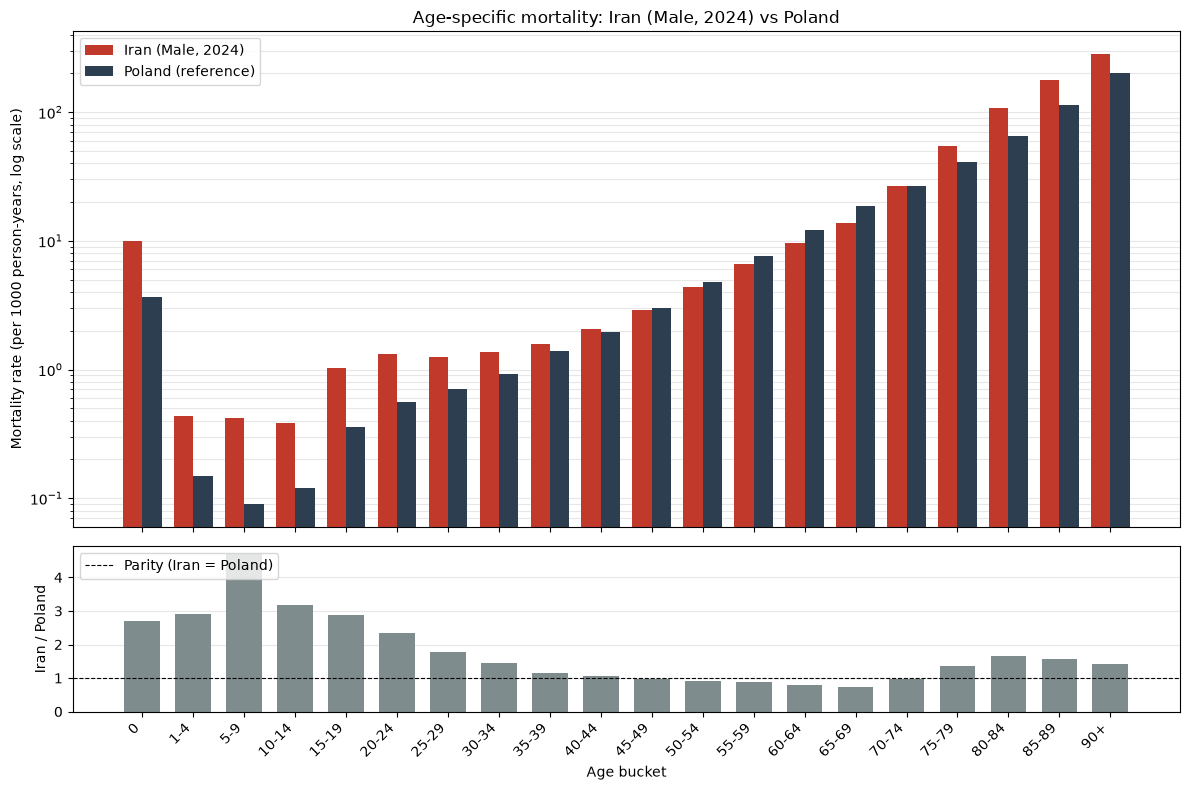

Saved figure to C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\results\figures\mortality_iran_vs_poland.png


In [9]:
# Build a long-form frame for matplotlib.
labels = [label for label, _ in POLAND_AGE_BUCKETS]
iran_vals = [comparison.filter(pl.col("age_bucket") == label)["iran_per_1000"].item()
             for label in labels]
poland_vals = [comparison.filter(pl.col("age_bucket") == label)["reference_per_1000"].item()
               for label in labels]

# Drop buckets where either side is missing so the chart stays clean.
clean = [
    (lab, ir, po)
    for lab, ir, po in zip(labels, iran_vals, poland_vals)
    if ir is not None and po is not None and np.isfinite(ir) and np.isfinite(po)
]
clean_labels = [c[0] for c in clean]
clean_iran = np.array([c[1] for c in clean])
clean_poland = np.array([c[2] for c in clean])
ratios = clean_iran / clean_poland

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)
x = np.arange(len(clean_labels))
width = 0.38

# Top: side-by-side bars.
ax1.bar(x - width / 2, clean_iran, width, label="Iran (Male, 2024)", color="#c0392b")
ax1.bar(x + width / 2, clean_poland, width, label="Poland (reference)", color="#2c3e50")
ax1.set_yscale("log")
ax1.set_ylabel("Mortality rate (per 1000 person-years, log scale)")
ax1.set_title("Age-specific mortality: Iran (Male, 2024) vs Poland")
ax1.legend(loc="upper left")
ax1.grid(True, axis="y", alpha=0.3, which="both")
ax1.set_axisbelow(True)

# Bottom: ratio (Iran / Poland). Reference line at 1.0 = parity.
ax2.bar(x, ratios, width=0.7, color="#7f8c8d")
ax2.axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="Parity (Iran = Poland)")
ax2.set_ylabel("Iran / Poland")
ax2.set_xticks(x)
ax2.set_xticklabels(clean_labels, rotation=45, ha="right")
ax2.set_xlabel("Age bucket")
ax2.legend(loc="upper left")
ax2.grid(True, axis="y", alpha=0.3)
ax2.set_axisbelow(True)

plt.tight_layout()
fig_path = FIG_DIR / "mortality_iran_vs_poland.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved figure to {fig_path}")


## 6. Persist the table

`data/mortality_iran.json` is the canonical artifact consumed by the
Markov model in `notebooks/03_psa_simulation.ipynb`. We write it
here in the same schema as `data/mortality.json` (Poland) so the
model can read either file by switching a single path.

We also write a side-by-side comparison CSV to
`outputs/sheets/mortality_iran_vs_poland.csv` for the appendix.


In [ ]:
write_mortality_json(iran_table, OUTPUT_JSON)
print(f"Wrote {OUTPUT_JSON}")

# Sanity: read it back and validate.
reloaded = json.loads(OUTPUT_JSON.read_text(encoding="utf-8"))
assert reloaded["use_age_specific"] is True
assert all(
    v is not None for v in reloaded["age_specific"].values()
), "Reloaded table should have no nulls; the WPP method filled all buckets."
print("Reloaded table: all 20 buckets present, none null.")

# Comparison CSV for the thesis appendix.
sheets_dir = PROJECT_ROOT / "outputs" / "sheets"
sheets_dir.mkdir(parents=True, exist_ok=True)
comparison.write_csv(sheets_dir / "mortality_iran_vs_poland.csv")
print(f"Wrote {sheets_dir / 'mortality_iran_vs_poland.csv'}")

Wrote C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\data\mortality_iran.json
Reloaded table: all 20 buckets present, none null.
Wrote C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\outputs\sheets\mortality_iran_vs_poland.csv


## Summary

* Iran (Male, 2024) crude rate: **5.228 per 1000 person-years**
  (vs Poland 12.8). Iran's crude rate is lower because its age
  distribution is much younger than Poland's; the age-specific
  rates are higher across most buckets.
* Infant mortality: Iran **9.95 per 1000** vs Poland **3.69 per
  1000** (ratio 2.7).
* Working-age (20-40): Iran 1.2-1.6 per 1000 vs Poland 0.6-1.4 per
  1000. Iran is roughly comparable to slightly higher.
* Old-age (70+): Iran rises steeply; at 90+ Iran is 28.4% per
  year vs Poland 20% (a 1.4x ratio), reflecting Iran's older
  generation's higher cardiovascular and metabolic burden.
* All 20 Poland buckets are filled with finite values - the WPP
  method gives a complete table without the cohort method's
  "growing cohort" gaps.

**Artifacts written:**

* `data/mortality_iran.json` - the canonical Iran mortality input
  for the Markov model.
* `app/results/figures/mortality_iran_vs_poland.png` - the comparison
  figure for the thesis.
* `outputs/sheets/mortality_iran_vs_poland.csv` - the comparison
  table as CSV for the appendix.
